# Task 1: Load the dataset into a DataFrame


In [1]:
#import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#load the dataset
df = pd.read_csv('ecommerce.csv')

# Task 2: Explore the data (head,info,descripe)


In [3]:
df.head()

,\tEmail,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   	Email                500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time on App           500 non-null    float64
 4   Time on Website       500 non-null    float64
 5   Length of Membership  500 non-null    float64
 6   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


In [7]:
df.describe()

,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.00000,500.000000
mean,12.052620,37.060480,3.53336,499.314240
std,0.994418,1.010555,0.99926,79.314764
min,8.510000,33.910000,0.27000,256.670000
25%,11.390000,36.347500,2.93000,445.037500
50%,11.980000,37.070000,3.53500,498.890000
75%,12.752500,37.720000,4.13000,549.312500
max,15.130000,40.010000,6.92000,765.520000


# Task 3: Data cleaning

In [10]:
#check missing values
df.isnull().sum()

\tEmail                 0
Address                 0
Avatar                  0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [14]:
#drop unneeded features
df.columns = df.columns.str.strip()
df=df.drop(columns= ['Email', 'Address', 'Avatar'])

In [15]:
#drop duplicated values
df=df.drop_duplicates()

In [19]:
#detect outliers

#calc Q1, Q3, IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

#outliers boundaries
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

#rows containing any outlier
outliers = ((df < lower) | (df > upper))
df_outliers = df[outliers.any(axis=1)]

Time on App               1.3625
Time on Website           1.3725
Length of Membership      1.2000
Yearly Amount Spent     104.2750
dtype: float64


In [20]:
df.shape

(500, 4)

In [23]:
#remove outliers
condition = (df >= lower) & (df <= upper)
df=df[condition.all(axis=1)]

In [24]:
df.shape

(479, 4)

# Task 5: Prepare the data for modeling

In [29]:
#Features
X = df[['Time on App',
        'Time on Website',
        'Length of Membership']]

#Target
y = df['Yearly Amount Spent']

In [30]:
#Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Task 6: Model training

In [31]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

# Task 7: Evaluation

In [32]:
print("Intercept:", lm.intercept_)

Intercept: -196.14046045152168


In [33]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Time on App,38.451541
Time on Website,0.366449
Length of Membership,62.140751


In [34]:
predictions = lm.predict(X_test)

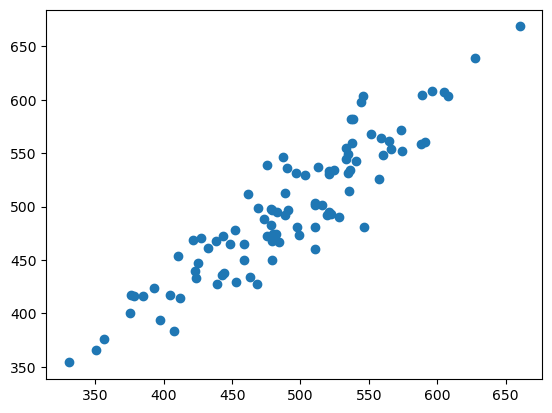

In [35]:
plt.scatter(y_test,predictions)

C:\Users\ruqay\AppData\Local\Temp\ipykernel_34048\1326397652.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-predictions),bins=50);


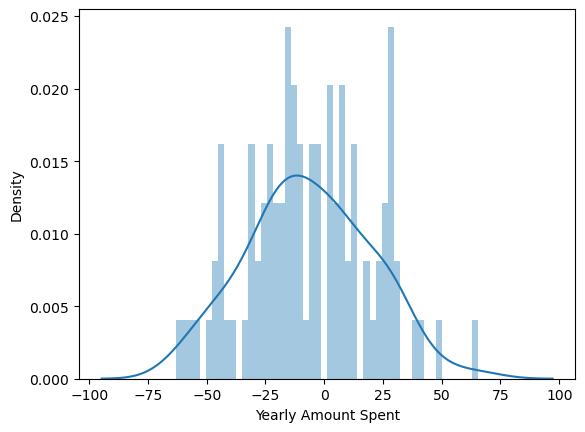

In [36]:
sns.distplot((y_test-predictions),bins=50);

In [37]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 21.978955030007853
MSE: 721.4298873170698
RMSE: 26.859446891495548
